# UC San Diego: Neural Data Science
## From Personal SSVEP EEG to Public Benchmark Decoding

## Permissions

Place an `X` in the appropriate bracket below to specify if you would like your group's project to be made available to the public. (Note that student names will be included (but PIDs will be scraped from any groups who include their PIDs).

* [  ] YES - make available
* [ x ] NO - keep private

# Group Members and Group Name

Group Members: Edwin Ruiz

Group Name: NeuroDecode

# Overview

This project analyzes steady-state visually evoked potential (SSVEP) EEG as a neural data systems pipeline. I started from a private OpenBCI/OpenVEP pilot recording, then used the public Wang2016 / Tsinghua SSVEP benchmark for the reproducible model comparison. The main question is whether frequency-locked EEG can be represented and modeled well enough to decode the visual target a person is attending to. The main result is that SSVEP-specific models, especially CCA and TRCA, decode the public benchmark far above 25% chance and outperform simple target-frequency power.

<h4 align="center"> measurement → preprocessing → representation → modeling → inference → action </h4>

## Research Question

<div align="center"><b>Can SSVEP EEG signals be transformed into frequency-based representations that reliably decode intended visual targets, and does performance improve when the model is matched to SSVEP physiology?</b></div>

<a id="background"></a>

# Background & Prior Work

Brain-computer interfaces (BCIs) translate neural activity into actionable outputs without requiring normal motor behavior. SSVEP is a useful non-invasive BCI paradigm because flickering visual stimuli evoke oscillatory EEG responses at corresponding frequencies, especially over occipital visual cortex. This gives the neural signal a known frequency structure that can be used for decoding visual attention and for downstream control, such as spelling systems, cursor movement, and assistive interfaces.

This project builds from a prior private OpenBCI/OpenVEP recording setup. In that earlier work, I recorded 8-channel EEG while attending to four flickering targets at 8, 10, 12, and 15 Hz, and the decoded class could be mapped to cursor-control directions. For this project, I treat the private recording as the pilot measurement system rather than the only source of evidence. The main reproducible analysis uses the public Wang2016 / Tsinghua SSVEP benchmark through MOABB, so the same frequency-representation question can be tested across multiple subjects without publishing personal brain recordings.

Prior SSVEP work motivates the model comparison. Wang et al. describe visual-evoked-potential BCIs as a practical route for high-throughput non-invasive control. Nakanishi et al. show that task-related component analysis (TRCA) can improve SSVEP detection by learning reproducible trial structure from calibration data. Canonical correlation analysis (CCA) is also a standard SSVEP method because it directly compares EEG with sine/cosine reference signals at candidate flicker frequencies. These studies support the main idea in this project: the same raw EEG can look weak or strong depending on how it is represented and what assumptions the model makes.

References:

- [Wang, Y., Gao, X., Hong, B., & Gao, S. (2008). Brain-computer interfaces based on visual evoked potentials. IEEE Engineering in Medicine and Biology Magazine, 27(5), 64-71.](https://doi.org/10.1109/MEMB.2008.923958)
- [Nakanishi, M., Wang, Y., Chen, X., Wang, Y.-T., Gao, X., & Jung, T.-P. (2018). Enhancing detection of SSVEPs for a high-speed brain speller using task-related component analysis. IEEE Transactions on Biomedical Engineering, 65(1), 104-112.](https://doi.org/10.1109/TBME.2017.2694818)
- [Hsu, W. Y., Yeh, C. L., Lee, P. L., et al. (2020). Extraction of high-frequency SSVEP for BCI control using iterative filtering based empirical mode decomposition. IEEE Access, 8, 49305-49315.](https://doi.org/10.1109/ACCESS.2020.2979024)
- [Jayaram, V. & Barachant, A. (2018). MOABB: Trustworthy algorithm benchmarking for BCIs. Journal of Machine Learning Research, 19(35), 1-5.](https://www.jmlr.org/papers/v19/18-238.html)
- [Wang2016 dataset entry in MOABB documentation.](https://moabb.neurotechx.com/docs/generated/moabb.datasets.Wang2016.html)

# Hypothesis

<div align="center"><b>Simple target-frequency power will detect some structure, but SSVEP-specific models such as CCA and TRCA will decode targets more accurately because they model frequency-locked neural responses in visual cortex.</b></div>

# Dataset(s)

| Dataset | Data Type | Role in Project | Public? |
| --- | --- | --- | --- |
| Private OpenBCI/OpenVEP pilot | 8-channel EEG, 250 Hz, four SSVEP classes at 8, 10, 12, and 15 Hz | Built the measurement-to-action pipeline and motivated the analysis question | No raw personal EEG in public repo |
| Wang2016 / Tsinghua SSVEP benchmark through MOABB | 64-channel EEG, 250 Hz, 40 SSVEP classes, 6-second trials | Reproducible public validation and final model comparison | Yes |

The private recording was collected in a prior OpenBCI/OpenVEP BCI setup. I use it here as the pilot dataset that shaped the question and pipeline, but I do not pool those trials with Wang2016 because the hardware, channel montage, number of subjects, and acquisition conditions are different. The final model-comparison results come from Wang2016 subjects 1-6. I selected the four target frequencies that match the private pilot: 8, 10, 12, and 15 Hz. This gives 144 selected public trials, with 25% chance accuracy.

# Representation and Models

The same raw EEG signal can lead to different conclusions depending on representation.

- **Target-frequency power:** estimate power near candidate flicker frequencies. This is interpretable but weak.
- **CCA:** compare each EEG trial to sine/cosine reference signals at each candidate SSVEP frequency.
- **TRCA:** use calibration labels to learn class-specific spatial filters and templates.
- **Filter-bank variants:** repeat decoding over multiple frequency bands, then combine scores.

This directly follows the course framing:

<h5 align="center">
data → representation → model → inference → action
</h5>

# Data Wrangling

For the public analysis, I use `scripts/run_wang2016_expansion.py` to load Wang2016 through MOABB, select subjects 1-6, keep only the 8/10/12/15 Hz labels, and compare occipital (`O1`, `Oz`, `O2`) with parieto-occipital (`PO3`, `POz`, `PO4`, `O1`, `Oz`, `O2`) channel sets. The same workflow is also shown in the detailed analysis notebook: [notebooks/COGS138_Public_SSVEP_Expansion_MOABB.ipynb](COGS138_Public_SSVEP_Expansion_MOABB.ipynb) ([view HTML](COGS138_Public_SSVEP_Expansion_MOABB.html)). The script writes the compact results table to `results/wang2016_expanded_model_comparison.csv`, and this report reads that table for the main figures.

For my private OpenBCI pilot, the saved OpenVEP trial arrays were shaped as `(trials, channels, samples)`. I reconstructed the labels from the same seeded trial-order logic used in the OpenVEP script. I keep those raw personal EEG arrays outside the public repo, so they are useful for my local pipeline reference but are not needed to reproduce the public Wang2016 result.

# Data Cleaning

For Wang2016, MOABB handles the main dataset loading and event alignment. After that, I crop each trial to the observation window being tested and keep the same four target classes across every model. For the private pilot, the OpenVEP acquisition script had already saved trial-level arrays after filtering, event alignment, baseline correction, and segmentation. My remaining step there was to crop away the first 0.2 seconds of baseline and analyze the stimulus-response window.

So the main cleaning choice here is not a large artifact-rejection pipeline. It is making sure every model sees a consistent EEG window, so target power, CCA, TRCA, and filter-bank variants are compared fairly.

# Data Visualization

In this final project report, I use three figures to answer the research question: best decoder accuracy by EEG window, model comparison at the short 1.2-second window, and a direct comparison between simple target-power representation and SSVEP-specific CCA/TRCA models. The detailed public analysis notebook has the setup and intermediate outputs for the public benchmark analysis.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

results_path = Path("../results/wang2016_expanded_model_comparison.csv")
expanded_results = pd.read_csv(results_path)
expanded_results.head()

,subjects,window_duration_seconds,channel_set,channels,trials,samples,model,accuracy,correct,binomial_p_value,permutation_p_value
0,"1,2,3,4,5,6",1.2,occipital,3,144,301,target_power,0.416667,60,8.796364e-06,0.0002
1,"1,2,3,4,5,6",1.2,occipital,3,144,301,cca,0.805556,116,2.680998e-44,0.0002
2,"1,2,3,4,5,6",1.2,occipital,3,144,301,filter_bank_cca,0.673611,97,1.418193e-26,0.0002
3,"1,2,3,4,5,6",1.2,occipital,3,144,301,trca_cross_validated,0.861111,124,1.121595e-53,0.0002
4,"1,2,3,4,5,6",1.2,occipital,3,144,301,filter_bank_trca_cross_validated,0.798611,115,3.229622e-43,0.0002


## Public Dataset Subset

The public expansion used subjects 1-6 from Wang2016 and selected the four frequencies that matched the private OpenBCI pilot: **8, 10, 12, and 15 Hz**.

This produced 144 selected public trials. Chance accuracy is 25%.

In [2]:
best_result_indices = expanded_results.groupby(['window_duration_seconds', 'channel_set'])['accuracy'].idxmax()
summary_table = expanded_results.loc[best_result_indices].reset_index(drop=True)

summary_table[['window_duration_seconds', 'channel_set', 'model', 'accuracy', 'correct', 'trials', 'binomial_p_value', 'permutation_p_value']]

,window_duration_seconds,channel_set,model,accuracy,correct,trials,binomial_p_value,permutation_p_value
0,1.2,occipital,trca_cross_validated,0.861111,124,144,1.121595e-53,0.0002
1,1.2,parieto_occipital,cca,0.930556,134,144,9.342440e-68,0.0002
2,2.0,occipital,trca_cross_validated,0.944444,136,144,5.061435e-71,0.0002
3,2.0,parieto_occipital,cca,0.958333,138,144,1.657233e-74,0.0002
4,4.0,occipital,trca_cross_validated,0.993056,143,144,8.706611e-85,0.0002
5,4.0,parieto_occipital,trca_cross_validated,1.000000,144,144,2.010765e-87,0.0002
6,6.0,occipital,trca_cross_validated,0.993056,143,144,8.706611e-85,0.0002
7,6.0,parieto_occipital,cca,0.993056,143,144,8.706611e-85,0.0002


## Visualization 1: Best Decoder Accuracy by Window

This plot asks whether longer EEG windows improve decoding and whether channel selection matters.

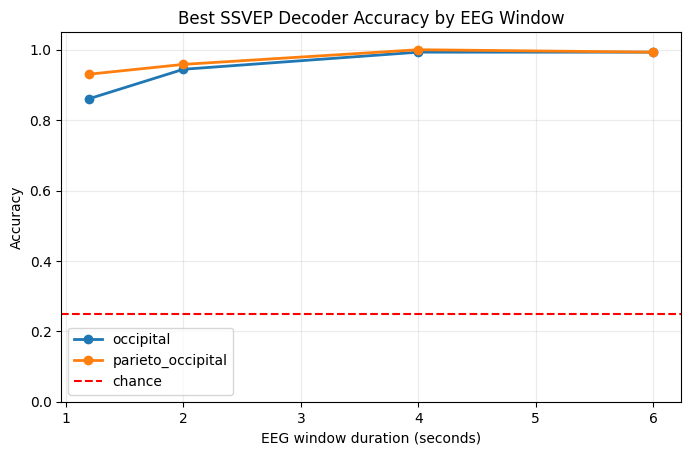

In [3]:
plt.figure(figsize=(8, 4.8))

for channel_set, channel_results in summary_table.groupby('channel_set'):
    plt.plot(channel_results['window_duration_seconds'],
             channel_results['accuracy'],
             marker='o',
             linewidth=2,
             label=channel_set)

plt.axhline(0.25, color='red', linestyle='--', label='chance')
plt.title('Best SSVEP Decoder Accuracy by EEG Window')
plt.xlabel('EEG window duration (seconds)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

**Interpretation:** accuracy increases as more SSVEP signal is observed. Even at 1.2 seconds, SSVEP-specific models are far above chance. Longer windows approach ceiling performance.

## Visualization 2: Model Comparison at 1.2 Seconds

This plot asks whether the model choice matters when the EEG window is short and closer to a real-time BCI setting.

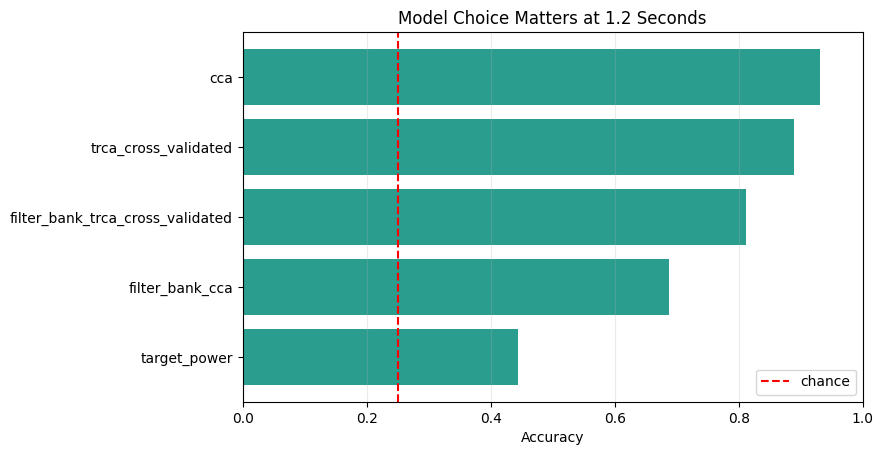

In [4]:
short_window_results = expanded_results[(expanded_results['window_duration_seconds'] == 1.2) &
                                        (expanded_results['channel_set'] == 'parieto_occipital')]
short_window_results = short_window_results.sort_values('accuracy')

plt.figure(figsize=(8, 4.8))
plt.barh(short_window_results['model'], short_window_results['accuracy'], color='#2a9d8f')
plt.axvline(0.25, color='red', linestyle='--', label='chance')
plt.title('Model Choice Matters at 1.2 Seconds')
plt.xlabel('Accuracy')
plt.xlim(0, 1.0)
plt.legend()
plt.grid(axis='x', alpha=0.25)
plt.show()

**Interpretation:** target-frequency power is above chance but much weaker than CCA/TRCA. The neural signal is present, but the representation/model determines whether it is recoverable.

## Visualization 3: CCA vs TRCA vs Target Power

This plot compares a simple representation against SSVEP-specific methods across observation windows.

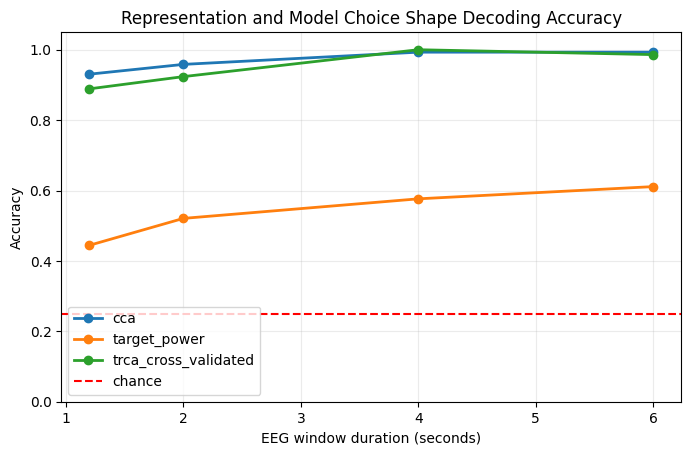

In [5]:
selected_models = expanded_results[(expanded_results['channel_set'] == 'parieto_occipital') &
                                   (expanded_results['model'].isin(['target_power', 'cca', 'trca_cross_validated']))]

plt.figure(figsize=(8, 4.8))

for model_name, model_results in selected_models.groupby('model'):
    plt.plot(model_results['window_duration_seconds'],
             model_results['accuracy'],
             marker='o',
             linewidth=2,
             label=model_name)

plt.axhline(0.25, color='red', linestyle='--', label='chance')
plt.title('Representation and Model Choice Shape Decoding Accuracy')
plt.xlabel('EEG window duration (seconds)')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Data Analysis & Results

## Statistical Result

All major CCA/TRCA results were significant against 25% chance. At the short 1.2-second window, parieto-occipital CCA decoded 134/144 trials correctly for 93.1% accuracy, with binomial p = 9.34e-68 and permutation p = 0.0002 using 5000 label shuffles. At the longer 4.0-second window, parieto-occipital cross-validated TRCA decoded 144/144 trials correctly, with binomial p = 2.01e-87 and permutation p = 0.0002.

The permutation value is the minimum nonzero value from `(extreme_count + 1) / (permutations + 1)`. The practical interpretation is that the result is not only statistically above chance; it is strong enough to support the project claim that SSVEP-specific representations and models are better matched to visual-cortex frequency-locking than simple target-power features.

# Neural Data Systems Interpretation

1. **Neural data source:** EEG measures voltage fluctuations at the scalp. SSVEP responses are strongest over visual cortex
2. **Representation:** raw time series were transformed into frequency/reference-signal structure
3. **Computational method:** target power, CCA, filter-bank CCA, TRCA, and filter-bank TRCA were compared
4. **Function:** decode which visual flicker frequency the subject attended
5. **Mechanism:** frequency-locked visual cortical responses make the attended stimulus class measurable
6. **Limitations:** scalp EEG is noisy, subject-specific calibration matters, and longer windows improve accuracy but reduce real-time responsiveness
7. **Extension:** decoded classes can drive a BCI action layer, such as cursor/game control, when confidence and safety thresholds are met

# Conclusion & Discussion

My private OpenBCI pilot gave me the full BCI pipeline on my own recording, but the public Wang2016 expansion is what makes the result reproducible and statistically stronger. The main finding is that adding more data alone is not the whole answer. The method has to match the structure of the neural signal.

Simple frequency power can miss structure that CCA/TRCA can recover. This matters because representation determines what patterns are even detectable. For BCI systems, this also affects whether a model can move from passive analysis to an action/control layer.

There are still limitations. Longer windows improve decoding but make real-time control slower. TRCA benefits from calibration labels, so it may not transfer instantly to a new person without adaptation. I also keep the private pilot data out of the public repo, so the public benchmark is the evidence used for reproducible evaluation. Future work should test another public SSVEP dataset, add stronger cross-subject transfer evaluation, and connect the decoder to a safety-gated local control interface.

# Reproducibility Notes

The public expansion can be reproduced from the repository root with:

```bash
python -m pip install -r requirements.txt
python scripts/run_wang2016_expansion.py
```

The public Wang2016 data are downloaded through MOABB into a local cache. My raw personal OpenBCI recordings are intentionally excluded from the public repository and are not needed to reproduce the public validation figures.